In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
#Set random seeds for reproductivity
np.random.seed(42)

In [3]:
#create sensor data
n_samples=1000

In [4]:
# Normal operation (80% of data)
normal_data=np.random.normal(loc=[50,45,60],scale=[5,4,6],size=(800,3))

In [5]:
# Equipment failing (10% of data) - slightly different pattern
failing_data=np.random.normal(loc=[55,52,65],scale=[8,7,9],size=(100,3))

In [7]:
# Sensor glitches (10% of data) - completely random
glitch_data =np.random.uniform(low=[0,0,0],high=[100,100,100],size=(100,3))

In [8]:
#Combine all data
X=np.vstack([normal_data,failing_data,glitch_data])

In [9]:
# Create labels for evaluation (we know ground truth here)
labels = np.array([0]*800 + [1]*100 + [2]*100)  # 0=normal, 1=failing, 2=glitch

In [11]:
df=pd.DataFrame(X,columns=['Sensor_A','Sensor_B','Sensor_C'])
df['True_labels']=labels


In [12]:
df.shape

(1000, 4)

In [13]:
df['True_labels'].value_counts()

True_labels
0    800
1    100
2    100
Name: count, dtype: int64

In [14]:
df.head(10)

,Sensor_A,Sensor_B,Sensor_C,True_labels
0,52.483571,44.446943,63.886131,0
1,57.615149,44.063387,58.595178,0
2,57.896064,48.069739,57.183154,0
3,52.712800,43.146329,57.205621,0
4,51.209811,37.346879,49.650493,0
5,47.188562,40.948676,61.885484,0
6,45.459880,39.350785,68.793893,0
7,48.871118,45.270113,51.451511,0
8,47.278086,45.443690,53.094039,0
9,51.878490,42.597445,58.249838,0


In [17]:
#select features
X=df.drop('True_labels',axis=1).values

#scale
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

X_scaled.shape

(1000, 3)

In [18]:
X_scaled[0]

array([ 0.1727429 , -0.17429344,  0.36324351])

Why important:
Each sensor might measure different ranges:

Temperature: 40-60°C
Vibration: 40-50 units
Pressure: 50-70 kPa

Without scaling, temperature dominates distance calculation. Scaling makes all equal.

In [19]:
#Find k_distance graph
neighbors= NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)
distances, indices = neighbors.kneighbors(X_scaled)


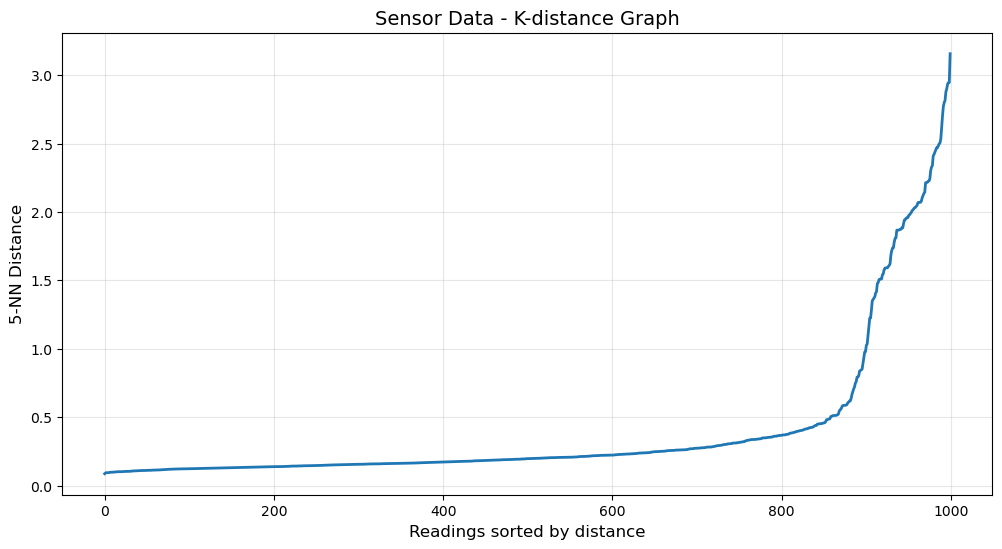

In [20]:
# Sort distances to 5th neighbor
distances_sorted = np.sort(distances[:, 4], axis=0)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(distances_sorted, linewidth=2)
plt.ylabel('5-NN Distance', fontsize=12)
plt.xlabel('Readings sorted by distance', fontsize=12)
plt.title('Sensor Data - K-distance Graph', fontsize=14)
plt.grid(True, alpha=0.3)

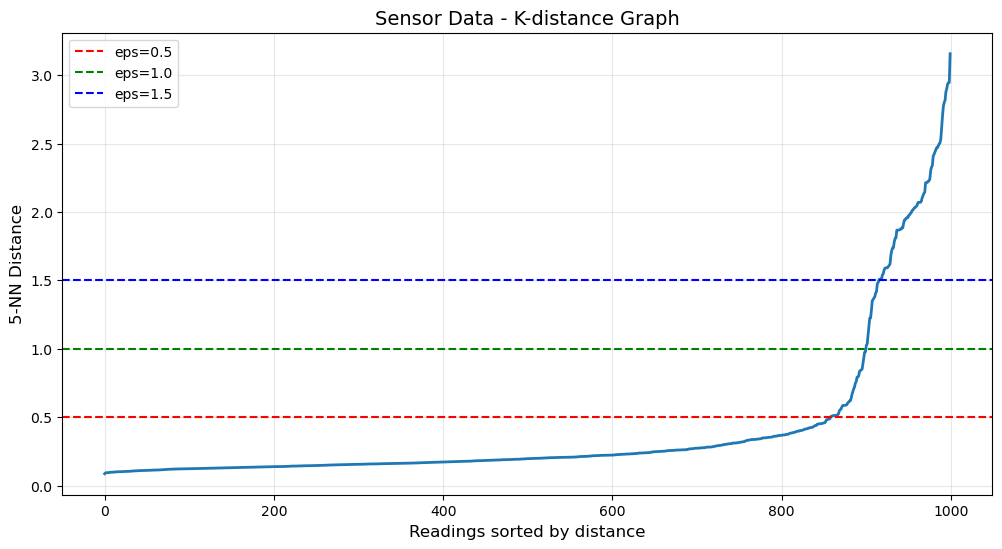

In [21]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(distances_sorted, linewidth=2)
plt.ylabel('5-NN Distance', fontsize=12)
plt.xlabel('Readings sorted by distance', fontsize=12)
plt.title('Sensor Data - K-distance Graph', fontsize=14)
plt.grid(True, alpha=0.3)

# Mark potential eps values
plt.axhline(y=0.5, color='r', linestyle='--', label='eps=0.5')
plt.axhline(y=1.0, color='g', linestyle='--', label='eps=1.0')
plt.axhline(y=1.5, color='b', linestyle='--', label='eps=1.5')
plt.legend()
plt.show()

In [22]:
# TRAIN DBSCAN
# Use eps from elbow (let's try 1.0)
dbscan=DBSCAN(eps=1.0,min_samples=5)
clusters=dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = clusters

# Analyze
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of anomalies detected: {n_noise}")
print(f"\nCluster distribution:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

Number of clusters found: 1
Number of anomalies detected: 94

Cluster distribution:
DBSCAN_Cluster
-1     94
 0    906
Name: count, dtype: int64


In [25]:
# What did DBSCAN find vs reality?
print("=== COMPARISON WITH GROUND TRUTH ===\n")

# Normal readings (True_Label = 0)
normal_data = df[df['True_labels'] == 0]
normal_detected = normal_data[normal_data['DBSCAN_Cluster'] == -1]
print(f"Normal readings flagged as anomaly: {len(normal_detected)} / {len(normal_data)}")
print(f"False positive rate: {len(normal_detected) / len(normal_data) * 100:.2f}%")

# Failing equipment (True_Label = 1)
failing_data = df[df['True_labels'] == 1]
failing_detected = failing_data[failing_data['DBSCAN_Cluster'] == -1]
print(f"\nFailing equipment caught: {len(failing_detected)} / {len(failing_data)}")
print(f"Detection rate: {len(failing_detected) / len(failing_data) * 100:.2f}%")

# Sensor glitches (True_Label = 2)
glitch_data = df[df['True_labels'] == 2]
glitch_detected = glitch_data[glitch_data['DBSCAN_Cluster'] == -1]
print(f"\nSensor glitches caught: {len(glitch_detected)} / {len(glitch_data)}")
print(f"Detection rate: {len(glitch_detected) / len(glitch_data) * 100:.2f}%")

=== COMPARISON WITH GROUND TRUTH ===

Normal readings flagged as anomaly: 0 / 800
False positive rate: 0.00%

Failing equipment caught: 2 / 100
Detection rate: 2.00%

Sensor glitches caught: 92 / 100
Detection rate: 92.00%


In [27]:
print("Testing different eps values:\n")
print(f"{'EPS':<5} {'Anomalies':<12} {'False+ve':<12} {'Failing':<12} {'Glitch':<12}")
print("-" * 53)

for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(X_scaled)
    df['Cluster_temp'] = clusters
    
    # Count
    anomalies = list(clusters).count(-1)
    false_pos = len(df[(df['True_labels'] == 0) & (df['Cluster_temp'] == -1)])
    failing_caught = len(df[(df['True_labels'] == 1) & (df['Cluster_temp'] == -1)])
    glitch_caught = len(df[(df['True_labels'] == 2) & (df['Cluster_temp'] == -1)])
    
    print(f"{eps:<5} {anomalies:<12} {false_pos:<12} {failing_caught:<12} {glitch_caught:<12}")

Testing different eps values:

EPS   Anomalies    False+ve     Failing      Glitch      
-----------------------------------------------------
0.5   121          3            22           96          
0.7   107          1            12           94          
0.9   96           0            4            92          
1.1   92           0            0            92          
1.3   87           0            0            87          
1.5   69           0            0            69          


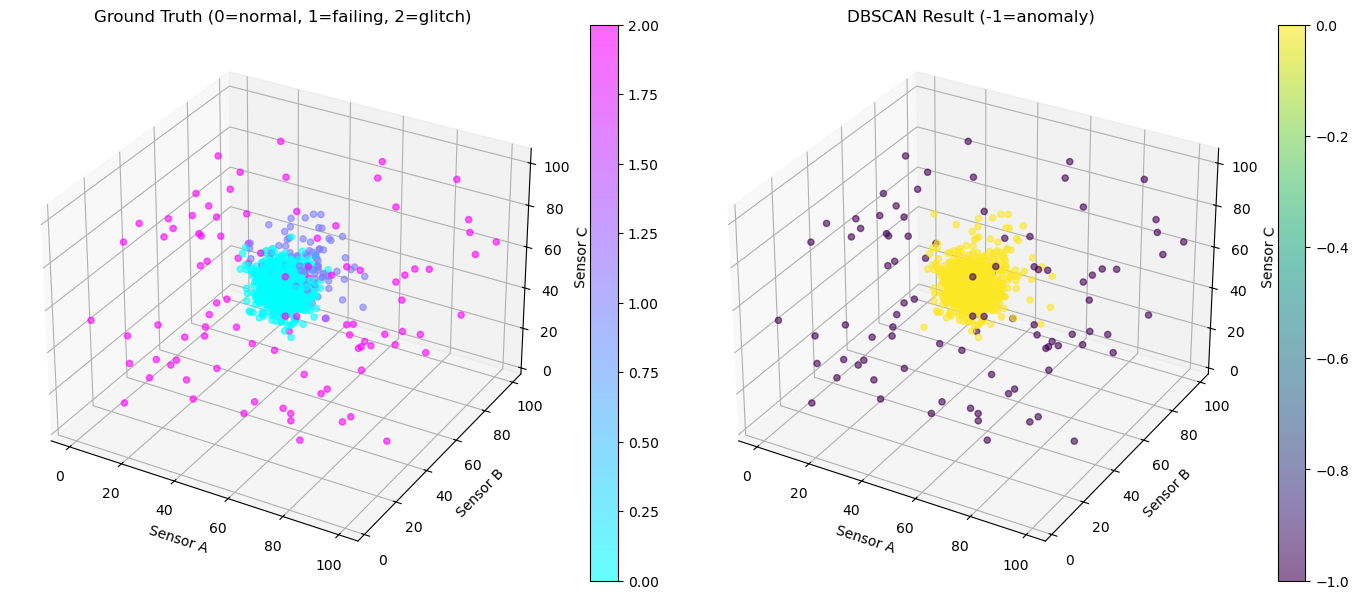

In [29]:
# 3D scatter plot (our data is 3D, perfect!)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# Subplot 1: True labels
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(df['Sensor_A'], df['Sensor_B'], df['Sensor_C'], 
                       c=df['True_labels'], cmap='cool', s=20, alpha=0.6)
ax1.set_xlabel('Sensor A')
ax1.set_ylabel('Sensor B')
ax1.set_zlabel('Sensor C')
ax1.set_title('Ground Truth (0=normal, 1=failing, 2=glitch)')
plt.colorbar(scatter1, ax=ax1)

# Subplot 2: DBSCAN clusters
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(df['Sensor_A'], df['Sensor_B'], df['Sensor_C'], 
                       c=df['DBSCAN_Cluster'], cmap='viridis', s=20, alpha=0.6)
ax2.set_xlabel('Sensor A')
ax2.set_ylabel('Sensor B')
ax2.set_zlabel('Sensor C')
ax2.set_title('DBSCAN Result (-1=anomaly)')
plt.colorbar(scatter2, ax=ax2)

plt.tight_layout()
plt.show()

In [31]:
print("=== PREDICTIVE MAINTENANCE INSIGHTS ===\n")

anomalies = df[df['DBSCAN_Cluster'] == -1]
failing = df[df['True_labels'] == 1]
glitches = df[df['True_labels'] == 2]

# What would maintenance team do?
print(f"Total readings analyzed: {len(df)}")
print(f"Anomalies flagged for review: {len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)")

print(f"\nIf maintenance team reviews {len(anomalies)} anomalies:")
print(f"  - They'll find {len(failing[failing['DBSCAN_Cluster'] == -1])} failing equipment (CRITICAL) 🚨")
print(f"  - They'll find {len(glitches[glitches['DBSCAN_Cluster'] == -1])} sensor glitches (replace sensor)")
print(f"  - False alarms: {len(anomalies) - len(failing[failing['DBSCAN_Cluster'] == -1]) - len(glitches[glitches['DBSCAN_Cluster'] == -1])}")

print(f"\n✅ Real-world impact:")
print(f"   Equipment failures prevented: {len(failing[failing['DBSCAN_Cluster'] == -1])}")
print(f"   Maintenance cost saved: ~${len(failing[failing['DBSCAN_Cluster'] == -1]) * 100000}")
print(f"   Downtime prevented: {len(failing[failing['DBSCAN_Cluster'] == -1]) * 8} hours")

=== PREDICTIVE MAINTENANCE INSIGHTS ===

Total readings analyzed: 1000
Anomalies flagged for review: 94 (9.4%)

If maintenance team reviews 94 anomalies:
  - They'll find 2 failing equipment (CRITICAL) 🚨
  - They'll find 92 sensor glitches (replace sensor)
  - False alarms: 0

✅ Real-world impact:
   Equipment failures prevented: 2
   Maintenance cost saved: ~$200000
   Downtime prevented: 16 hours
